In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

In [2]:
cluster_infos = []
years = range(2015,2025)
borders_path = r"C:\Users\darja\Complexity72h\complexity72_2026\ne_110m_admin_0_countries.gpkg"

for year in years:
    if year!= 2017: 
        # ── 1. Cluster summary (your data) ───────────────────────────────────────────
        clusters = pd.read_csv(
            f"C:\\Users\\darja\\Complexity72h\\complexity72_2026\\clustering\\barycenter\\kmeans_cluster_barycenters_k5_{year}.csv"
    )
        clusters["year"] = year
        cluster_infos.append(clusters)

#Normalize across all years for consistent color mapping
all_clusters = pd.concat(cluster_infos, ignore_index=True)

all_clusters_normalized = all_clusters.copy()

vars_to_encode = ["emission", "growth_rate", "gosif"]

for col in vars_to_encode:
    col_min, col_max = all_clusters_normalized[col].min(), all_clusters_normalized[col].max()
    scale = col_max - col_min
    if scale == 0:
        all_clusters_normalized[col] = 0.5
    else:
        all_clusters_normalized[col] = (all_clusters_normalized[col] - col_min) / scale

#all_clusters_normalized

Simple ranking from diff between emission and bio

In [ ]:
""" cluster_infos = []
years = range(2015,2025)
borders_path = r"C:/Users/darja/Complexity72h/complexity72_2026/ne_110m_admin_0_countries.gpkg"

ranking_diff_map = {1:'Strongly GOSIF', 2:'Moderately GOSIF', 3:'No emissions', 4:'Moderately Emission', 5:'Strongly Emission'}

for year in years:
    if year!= 2017: 
        # ── 1. Cluster summary (your data) ───────────────────────────────────────────
        clusters = pd.read_csv(
            f"C://Users//darja//Complexity72h//complexity72_2026//clustering//barycenter//kmeans_cluster_barycenters_k5_{year}.csv"
    )
        clusters['emission_norm'] = (clusters['emission'] - clusters['emission'].min()) / (clusters['emission'].max() - clusters['emission'].min())
        clusters['gosif_norm'] = (clusters['gosif'] - clusters['gosif'].min()) / (clusters['gosif'].max() - clusters['gosif'].min())
        clusters['growth_rate_norm'] = (clusters['growth_rate'] - clusters['growth_rate'].min()) / (clusters['growth_rate'].max() - clusters['growth_rate'].min())

        clusters['diff'] = clusters['gosif_norm'] / clusters['emission_norm']

        no_emission_condition = (clusters['emission_norm'] == 0) & (clusters['gosif_norm'] == 0)

        # 2. Sort by 'diff' ascending so the order is ready for ranking
        clusters.sort_values(by='diff', ascending=True, inplace=True)

        # 3. Create a temporary ranking for the rows that are NOT the special cluster
        # This counts 1, 2, 3, 4... for only the valid rows
        non_special_rows = ~no_emission_condition
        clusters.loc[non_special_rows, 'ranked_cluster'] = range(1, non_special_rows.sum() + 1)

        # 4. Shift any ranks that are >= 3 up by 1 to make room for cluster 3
        clusters.loc[clusters['ranked_cluster'] >= 3, 'ranked_cluster'] += 1

        # 5. Explicitly assign 3 to your special condition row(s)
        clusters.loc[no_emission_condition, 'ranked_cluster'] = 3

        # 6. Ensure the data type is integer (optional but recommended)
        clusters['ranked_cluster'] = clusters['ranked_cluster'].astype(int)
        
        clusters['ranked_cluster'] = clusters['ranked_cluster'].map(ranking_diff_map)
        clusters["year"] = year

        cluster_infos.append(clusters)

cluster_infos = pd.concat(cluster_infos, ignore_index=True)
cluster_infos.to_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv", index=False)

cluster_infos"
"""

,cluster,point_count,emission,growth_rate,gosif,emission_norm,gosif_norm,growth_rate_norm,diff,ranked_cluster,year
0,5,4320,35811.307227,2.756427,0.088911,0.624136,0.303175,0.569246,0.485752,Strongly GOSIF,2015
1,2,1830,57376.597000,2.033845,0.191053,1.000000,0.653116,0.000000,0.653116,Moderately GOSIF,2015
2,3,6715,3152.917789,2.342195,0.019603,0.054929,0.065727,0.242916,1.196583,Moderately Emission,2015
3,4,1778,13802.777063,3.303213,0.292302,0.240546,1.000000,1.000000,4.157203,Strongly Emission,2015
4,1,6894,1.377713,2.125667,0.000419,0.000000,0.000000,0.072337,NaN,No emissions,2015
5,3,4208,11482.824794,3.161038,0.022609,0.196197,0.075539,0.713959,0.385014,Strongly GOSIF,2016
6,5,3334,58524.902355,3.064399,0.155366,1.000000,0.530623,0.478578,0.530623,Moderately GOSIF,2016
7,4,1960,26638.652115,3.278476,0.292293,0.455163,1.000000,1.000000,2.197014,Moderately Emission,2016
8,2,5158,1973.029703,2.898826,0.043738,0.033705,0.147968,0.075295,4.390131,Strongly Emission,2016
9,1,6877,0.489089,2.867912,0.000573,0.000000,0.000000,0.000000,NaN,No emissions,2016


In [23]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# ── 0. Setup ──────────────────────────────────────────────────────────────────
# Assume you have a dict of dataframes, one per year:
# dfs = {2010: df_2010, 2011: df_2011, ...}
# Each df has columns: lat, lon, cluster, emission, gosif, growth_rate
years = range(2015, 2025)

full_df = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv")
dfs = {year: full_df[full_df[f'year'] == year] for year in years}


FEATURES = ['emission', 'gosif']  # as you said, drop growth_rate

def get_centroids(df, features=FEATURES, n_clusters=5):
    """Compute cluster centroids on chosen features."""
    return (
        df.groupby('cluster')[features]
        .mean()
        .sort_index()  # ensure consistent row order 1..5
    )

# ── 1. Compute centroids per year ─────────────────────────────────────────────
years = sorted(dfs.keys())
centroids = {yr: get_centroids(dfs[yr]) for yr in years}

# ── 2. Build label mapping relative to reference year ────────────────────────
reference_year = years[0]
ref_centroids = centroids[reference_year].values  # shape (5, 2)

label_mappings = {reference_year: {i+1: i+1 for i in range(5)}}  # identity

for yr in years[1:]:
    yr_centroids = centroids[yr].values  # shape (5, 2)

    # Cost matrix: pairwise distances between ref centroids and this year's
    cost_matrix = cdist(ref_centroids, yr_centroids, metric='euclidean')

    # Hungarian algorithm: finds optimal 1-to-1 assignment
    ref_idx, yr_idx = linear_sum_assignment(cost_matrix)

    # ref cluster (ref_idx+1) should be renamed to match yr cluster (yr_idx+1)
    # We want: yr_label → ref_label
    mapping = {}
    for r, y in zip(ref_idx, yr_idx):
        yr_label  = y + 1   # original label in this year
        ref_label = r + 1   # what it should be renamed to
        mapping[yr_label] = ref_label

    label_mappings[yr] = mapping
    print(f"{yr}: {mapping}")

# ── 3. Apply remapping to each dataframe ─────────────────────────────────────
dfs_aligned = {}
for yr in years:
    df = dfs[yr].copy()
    df['cluster_aligned'] = df['cluster'].map(label_mappings[yr])
    dfs_aligned[yr] = df
    dfs_aligned[yr].drop(columns=['ranked_cluster'], inplace=True)

2016: {np.int64(1): np.int64(1), np.int64(5): np.int64(2), np.int64(2): np.int64(3), np.int64(3): np.int64(4), np.int64(4): np.int64(5)}
2017: {}
2018: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(2): np.int64(5)}
2019: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(3): np.int64(5)}
2020: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(3): np.int64(5)}
2021: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3), np.int64(5): np.int64(4), np.int64(4): np.int64(5)}
2022: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3), np.int64(5): np.int64(4), np.int64(4): np.int64(5)}
2023: {np.int64(1): np.int64(1), np.int64(5): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(2): np.int64(5)}
2024: {np.int64(1): np.int64(1),

In [54]:
dfs_aligned

{2015:    cluster  point_count      emission  growth_rate     gosif  emission_norm  \
 0        5         4320  35811.307227     2.756427  0.088911       0.624136   
 1        2         1830  57376.597000     2.033845  0.191053       1.000000   
 2        3         6715   3152.917789     2.342195  0.019603       0.054929   
 3        4         1778  13802.777063     3.303213  0.292302       0.240546   
 4        1         6894      1.377713     2.125667  0.000419       0.000000   
 
    gosif_norm  growth_rate_norm      diff       ranked_cluster  year  \
 0    0.303175          0.569246  0.485752       Strongly GOSIF  2015   
 1    0.653116          0.000000  0.653116     Moderately GOSIF  2015   
 2    0.065727          0.242916  1.196583  Moderately Emission  2015   
 3    1.000000          1.000000  4.157203    Strongly Emission  2015   
 4    0.000000          0.072337       NaN         No emissions  2015   
 
    cluster_aligned  
 0                3  
 1                2  
 2    

Global template centroids:
                    emission_norm  gosif_norm
template_cluster_1       0.000000    0.000000
template_cluster_2       0.633882    0.398192
template_cluster_3       0.486232    0.214291
template_cluster_4       0.401251    0.879918
template_cluster_5       0.362711    0.333063

Label remappings per year:
  2015: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(3): np.int64(5)}
  2016: {np.int64(1): np.int64(1), np.int64(5): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(2): np.int64(5)}
  2018: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}
  2019: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}
  2020: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), 

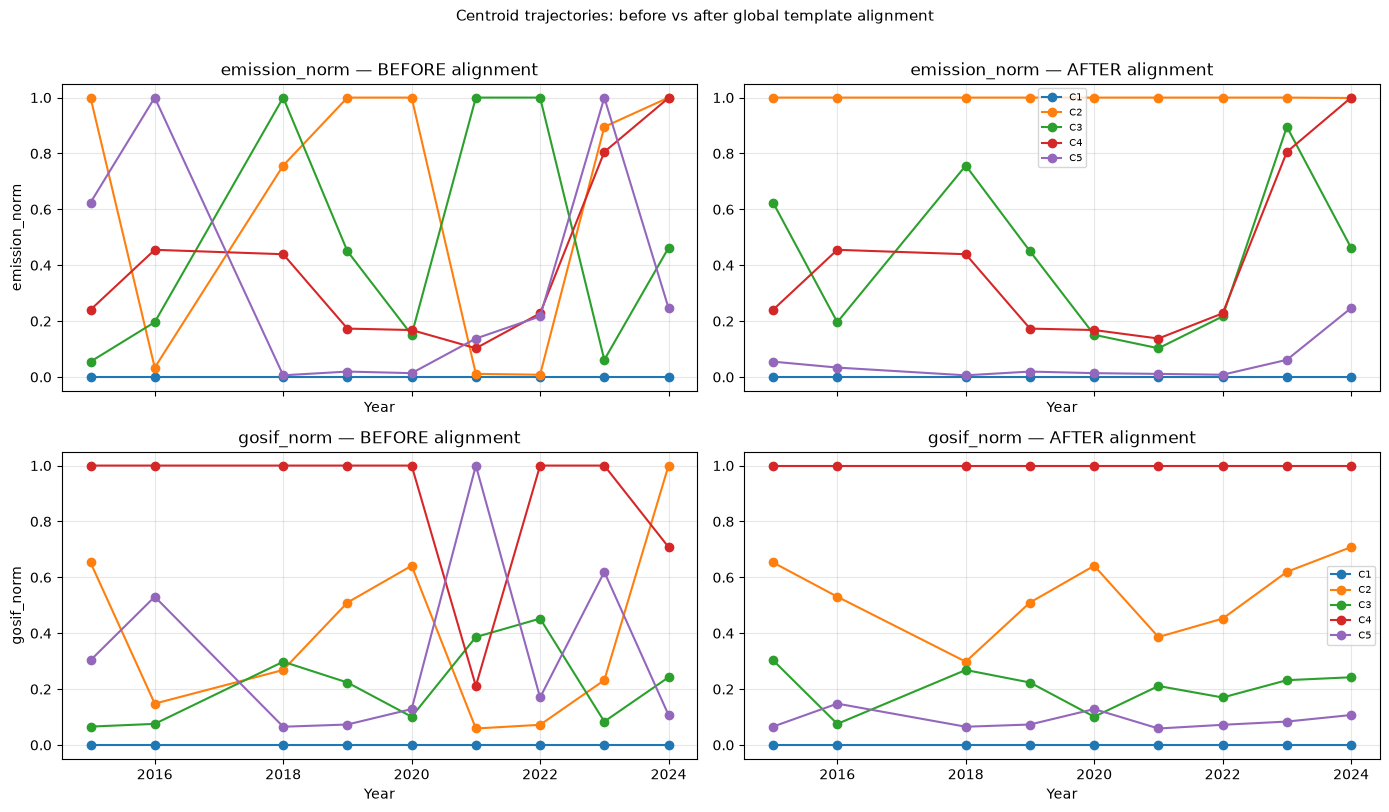

In [37]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# ── 0. Config ─────────────────────────────────────────────────────────────────
FEATURES    = ['emission_norm', 'gosif_norm']   # growth_rate excluded
N_CLUSTERS  = 5

# ── 1. Load your data ─────────────────────────────────────────────────────────
# Expects a dict: {year (int): pd.DataFrame}
# Each df must have columns: lat, lon, cluster, emission, gosif, growth_rate
#
# Example loader — adapt to your actual file structure:
#
# import glob, os
# dfs = {}
# for path in sorted(glob.glob("data/year_*.csv")):
#     yr = int(os.path.basename(path).split("_")[1].split(".")[0])
#     dfs[yr] = pd.read_csv(path)

# dfs = { 2010: df_2010, 2011: df_2011, ... }   ← your dict here

years = [2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  # exclude 2017

full_df = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv")
dfs = {year: full_df[full_df[f'year'] == year] for year in years}

# ── 2. Compute per-year centroids ─────────────────────────────────────────────
def get_centroids(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a (N_CLUSTERS x len(FEATURES)) DataFrame
    indexed by original cluster label (1..N_CLUSTERS).
    """
    c = df.groupby('cluster')[FEATURES].mean().sort_index()
    assert len(c) == N_CLUSTERS, \
        f"Expected {N_CLUSTERS} clusters, got {len(c)}"
    return c

centroids_raw = {yr: get_centroids(dfs[yr]) for yr in years}

# ── 3. Build global template (mean centroid across all years) ─────────────────
# Shape: (n_years, N_CLUSTERS, n_features)
all_centroid_arrays = np.stack([centroids_raw[yr].values for yr in years])

# Mean over years → (N_CLUSTERS, n_features)
# NOTE: this assumes cluster labels are already *roughly* consistent across years
# (which they may not be — see comment below). If your data is very inconsistent
# pre-alignment, consider bootstrapping: run the alignment iteratively 2-3 times,
# each time recomputing the template from the newly aligned centroids.
global_template = all_centroid_arrays.mean(axis=0)

print("Global template centroids:")
print(pd.DataFrame(global_template, columns=FEATURES,
                   index=[f'template_cluster_{i+1}' for i in range(N_CLUSTERS)]))

# ── 4. Align each year to the global template via Hungarian algorithm ──────────
def align_to_template(yr_centroids: np.ndarray,
                      template: np.ndarray) -> dict:
    """
    Returns mapping: {original_yr_label -> aligned_label}
    Minimises total Euclidean distance between matched centroid pairs.
    """
    cost_matrix = cdist(template, yr_centroids, metric='euclidean')  # (N, N)
    tmpl_idx, yr_idx = linear_sum_assignment(cost_matrix)
    # tmpl_idx[i] should be renamed to match yr cluster yr_idx[i]
    return {yr_idx[i] + 1: tmpl_idx[i] + 1 for i in range(N_CLUSTERS)}

label_mappings = {}
for yr in years:
    mapping = align_to_template(centroids_raw[yr].values, global_template)
    label_mappings[yr] = mapping

print("\nLabel remappings per year:")
for yr, m in label_mappings.items():
    print(f"  {yr}: {m}")

# ── 5. Apply remapping to each dataframe ──────────────────────────────────────
dfs_aligned = {}
for yr in years:
    df = dfs[yr].copy()
    df['cluster_aligned'] = df['cluster'].map(label_mappings[yr])
    dfs_aligned[yr] = df


# Iterative refinement (2-3 rounds is usually enough)
N_ITER = 10

for iteration in range(N_ITER):
    # Recompute template from currently aligned centroids
    aligned_centroid_arrays = np.stack([
        dfs_aligned[yr].groupby('cluster_aligned')[FEATURES].mean()
                        .sort_index().values
        for yr in years
    ])
    global_template = aligned_centroid_arrays.mean(axis=0)

    # Re-align all years to updated template
    for yr in years:
        mapping = align_to_template(
            centroids_raw[yr].values, global_template
        )
        label_mappings[yr] = mapping
        dfs_aligned[yr]['cluster_aligned'] = dfs_aligned[yr]['cluster'].map(mapping)

    print(f"Iteration {iteration+1} done.")


# ── 6. Sanity check: plot centroid trajectories before vs after ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for feat_idx, feat in enumerate(FEATURES):
    ax_before = axes[feat_idx * 2]
    ax_after  = axes[feat_idx * 2 + 1]

    for c in range(1, N_CLUSTERS + 1):
        # Before: raw centroid of whatever cluster label 'c' happened to be
        before_vals = [centroids_raw[yr].loc[c, feat] for yr in years]

        # After: centroid of the *aligned* cluster 'c'
        after_vals = []
        for yr in years:
            aligned_df = dfs_aligned[yr]
            val = aligned_df[aligned_df['cluster_aligned'] == c][feat].mean()
            after_vals.append(val)

        ax_before.plot(years, before_vals, marker='o', label=f'C{c}')
        ax_after.plot(years,  after_vals,  marker='o', label=f'C{c}')

    ax_before.set_title(f'{feat} — BEFORE alignment')
    ax_after.set_title(f'{feat} — AFTER alignment')
    ax_before.set_ylabel(feat)
    ax_after.legend(fontsize=7)

for ax in axes:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.suptitle('Centroid trajectories: before vs after global template alignment',
             fontsize=11, y=1.01)
plt.tight_layout()
#plt.savefig('alignment_sanity_check.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
all_points = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_classified_points_all_years.csv")
all_points

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,kmeans_cluster_2023,kmeans_cluster_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,1,1
1,-178.5,-89.5,1,1,1,1,1,1,1,1,1,1
2,-177.5,-89.5,1,1,1,1,1,1,1,1,1,1
3,-176.5,-89.5,1,1,1,1,1,1,1,1,1,1
4,-175.5,-89.5,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
21532,-31.5,83.5,3,2,2,5,5,5,2,2,3,1
21533,-30.5,83.5,3,2,2,5,5,5,2,2,3,1
21534,-29.5,83.5,3,2,2,5,5,5,2,2,3,1
21535,-28.5,83.5,3,2,2,5,5,5,2,2,3,1


In [46]:

# Inputs:
# all_points: lon, lat, kmeans_cluster_2015 ... kmeans_cluster_2024
# dfs_aligned: {year: df_year} with columns:
#   cluster, cluster_aligned, emission, growth_rate, gosif,
#   emission_norm, gosif_norm, growth_rate_norm, diff

all_points_aligned = all_points.copy()

vars_to_map = [
    "emission",
    "growth_rate",
    "gosif",
    "emission_norm",
    "gosif_norm",
    "growth_rate_norm",
    "diff",
]

years = sorted(dfs_aligned.keys())

for year in years:
    old_col = f"kmeans_cluster_{year}"
    if old_col not in all_points_aligned.columns:
        continue

    dfy = dfs_aligned[year].copy()

    required = ["cluster", "cluster_aligned"] + vars_to_map
    missing = [c for c in required if c not in dfy.columns]
    if missing:
        print(f"Skipping {year}, missing columns: {missing}")
        continue

    # If there are multiple rows per cluster, collapse to one row per old cluster.
    # 'first' for aligned label, 'mean' for numeric metrics.
    agg_spec = {"cluster_aligned": "first", **{v: "mean" for v in vars_to_map}}
    map_df = dfy.groupby("cluster", as_index=False).agg(agg_spec)

    # Align dtypes so map works reliably
    all_points_aligned[old_col] = pd.to_numeric(all_points_aligned[old_col], errors="coerce")
    map_df["cluster"] = pd.to_numeric(map_df["cluster"], errors="coerce")
    map_df["cluster_aligned"] = pd.to_numeric(map_df["cluster_aligned"], errors="coerce")

    # Map aligned cluster
    cluster_map = dict(zip(map_df["cluster"], map_df["cluster_aligned"]))
    all_points_aligned[f"aligned_cluster_{year}"] = all_points_aligned[old_col].map(cluster_map)

    # Map all requested variables from old cluster -> value
    for v in vars_to_map:
        value_map = dict(zip(map_df["cluster"], map_df[v]))
        all_points_aligned[f"{v}_{year}"] = all_points_aligned[old_col].map(value_map)

    # Optional nullable int for aligned cluster
    all_points_aligned[f"aligned_cluster_{year}"] = (
        all_points_aligned[f"aligned_cluster_{year}"].round().astype("Int64")
    )

# Quick check
for year in years:
    c = f"aligned_cluster_{year}"
    if c in all_points_aligned.columns:
        na_count = all_points_aligned[c].isna().sum()
        print(f"{year}: unmapped aligned clusters = {na_count}")

2015: unmapped aligned clusters = 0
2016: unmapped aligned clusters = 0
2018: unmapped aligned clusters = 0
2019: unmapped aligned clusters = 0
2020: unmapped aligned clusters = 0
2021: unmapped aligned clusters = 0
2022: unmapped aligned clusters = 0
2023: unmapped aligned clusters = 0
2024: unmapped aligned clusters = 0


In [58]:
all_points_not_aligned = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_classified_points_all_years.csv")
all_points_not_aligned

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,kmeans_cluster_2023,kmeans_cluster_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,1,1
1,-178.5,-89.5,1,1,1,1,1,1,1,1,1,1
2,-177.5,-89.5,1,1,1,1,1,1,1,1,1,1
3,-176.5,-89.5,1,1,1,1,1,1,1,1,1,1
4,-175.5,-89.5,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
21532,-31.5,83.5,3,2,2,5,5,5,2,2,3,1
21533,-30.5,83.5,3,2,2,5,5,5,2,2,3,1
21534,-29.5,83.5,3,2,2,5,5,5,2,2,3,1
21535,-28.5,83.5,3,2,2,5,5,5,2,2,3,1


In [60]:
clusters_not_aligned = pd.read_csv("C:\\Users\\darja\\Complexity72h\\complexity72_2026\\clustering\\kmeans_cluster_all_years.csv")
clusters_not_aligned

,cluster,point_count,emission,growth_rate,gosif,emission_norm,gosif_norm,growth_rate_norm,diff,ranked_cluster,year
0,5,4320,35811.307227,2.756427,0.088911,0.624136,0.303175,0.569246,0.485752,Strongly GOSIF,2015
1,2,1830,57376.597000,2.033845,0.191053,1.000000,0.653116,0.000000,0.653116,Moderately GOSIF,2015
2,3,6715,3152.917789,2.342195,0.019603,0.054929,0.065727,0.242916,1.196583,Moderately Emission,2015
3,4,1778,13802.777063,3.303213,0.292302,0.240546,1.000000,1.000000,4.157203,Strongly Emission,2015
4,1,6894,1.377713,2.125667,0.000419,0.000000,0.000000,0.072337,NaN,No emissions,2015
5,3,4208,11482.824794,3.161038,0.022609,0.196197,0.075539,0.713959,0.385014,Strongly GOSIF,2016
6,5,3334,58524.902355,3.064399,0.155366,1.000000,0.530623,0.478578,0.530623,Moderately GOSIF,2016
7,4,1960,26638.652115,3.278476,0.292293,0.455163,1.000000,1.000000,2.197014,Moderately Emission,2016
8,2,5158,1973.029703,2.898826,0.043738,0.033705,0.147968,0.075295,4.390131,Strongly Emission,2016
9,1,6877,0.489089,2.867912,0.000573,0.000000,0.000000,0.000000,NaN,No emissions,2016


In [62]:
for year in years:
    col_of_points = f"kmeans_cluster_{year}"
    cluster_info = clusters_not_aligned[clusters_not_aligned['year'] == year]

    all_points_not_aligned = all_points_not_aligned.merge(
        cluster_info[['cluster', 'emission', 'growth_rate', 'gosif']],
        left_on=col_of_points,
        right_on='cluster',
        how='left'
    )

all_points_not_aligned

MergeError: Passing 'suffixes' which cause duplicate columns {'cluster_y', 'growth_rate_y', 'gosif_y', 'gosif_x', 'cluster_x', 'growth_rate_x', 'emission_x', 'emission_y'} is not allowed.

In [63]:
vars_to_map = ["emission", "growth_rate", "gosif", "emission_norm", "gosif_norm", "growth_rate_norm", "diff"]

all_points_not_aligned_mapped = all_points_not_aligned[[
    col for col in all_points_not_aligned.columns
    if not any(col.startswith(f"{var_name}_") for var_name in vars_to_map)
 ]].copy()

for year in years:
    col_of_points = f"kmeans_cluster_{year}"
    if col_of_points not in all_points_not_aligned_mapped.columns:
        continue

    cluster_info = clusters_not_aligned[clusters_not_aligned["year"] == year].copy()

    required = ["cluster"] + vars_to_map
    missing = [col for col in required if col not in cluster_info.columns]
    if missing:
        print(f"Skipping {year}, missing columns: {missing}")
        continue

    map_df = (
        cluster_info[required]
        .groupby("cluster", as_index=False)
        .mean(numeric_only=True)
    )

    all_points_not_aligned_mapped[col_of_points] = pd.to_numeric(
        all_points_not_aligned_mapped[col_of_points], errors="coerce"
    )
    map_df["cluster"] = pd.to_numeric(map_df["cluster"], errors="coerce")

    for var_name in vars_to_map:
        value_map = dict(zip(map_df["cluster"], map_df[var_name]))
        all_points_not_aligned_mapped[f"{var_name}_{year}"] = (
            all_points_not_aligned_mapped[col_of_points].map(value_map)
        )

all_points_not_aligned_mapped.head()

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,...,gosif_norm_2023,growth_rate_norm_2023,diff_2023,emission_2024,growth_rate_2024,gosif_2024,emission_norm_2024,gosif_norm_2024,growth_rate_norm_2024,diff_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,...,0.0,0.151443,NaN,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
1,-178.5,-89.5,1,1,1,1,1,1,1,1,...,0.0,0.151443,NaN,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
2,-177.5,-89.5,1,1,1,1,1,1,1,1,...,0.0,0.151443,NaN,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
3,-176.5,-89.5,1,1,1,1,1,1,1,1,...,0.0,0.151443,NaN,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
4,-175.5,-89.5,1,1,1,1,1,1,1,1,...,0.0,0.151443,NaN,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN


In [64]:
import seaborn as sns

<Axes: xlabel='growth_rate_norm_2016', ylabel='Count'>

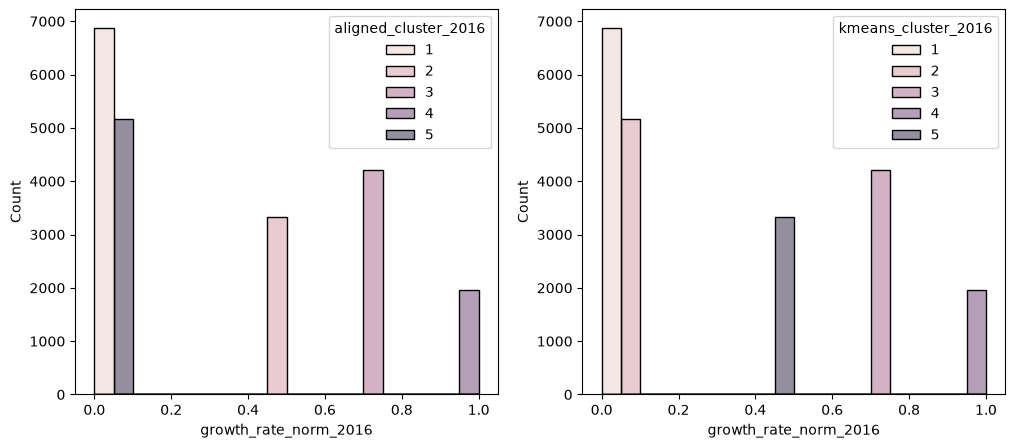

In [78]:
fig,axs = plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=all_points_aligned, x="growth_rate_norm_2016", hue="aligned_cluster_2016", fill=True, common_norm=False, alpha=0.5,ax=axs[0])
sns.histplot(data=all_points_not_aligned_mapped, x="growth_rate_norm_2016", hue="kmeans_cluster_2016", fill=True, common_norm=False, alpha=0.5,ax=axs[1])

In [47]:
all_points_aligned.head()

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,...,growth_rate_norm_2023,diff_2023,aligned_cluster_2024,emission_2024,growth_rate_2024,gosif_2024,emission_norm_2024,gosif_norm_2024,growth_rate_norm_2024,diff_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
1,-178.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
2,-177.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
3,-176.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
4,-175.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN


In [48]:
all_points_aligned.to_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_classified_points_all_years_aligned.csv", index=False)

# Cluster stats and comparison between aligned and not aligned

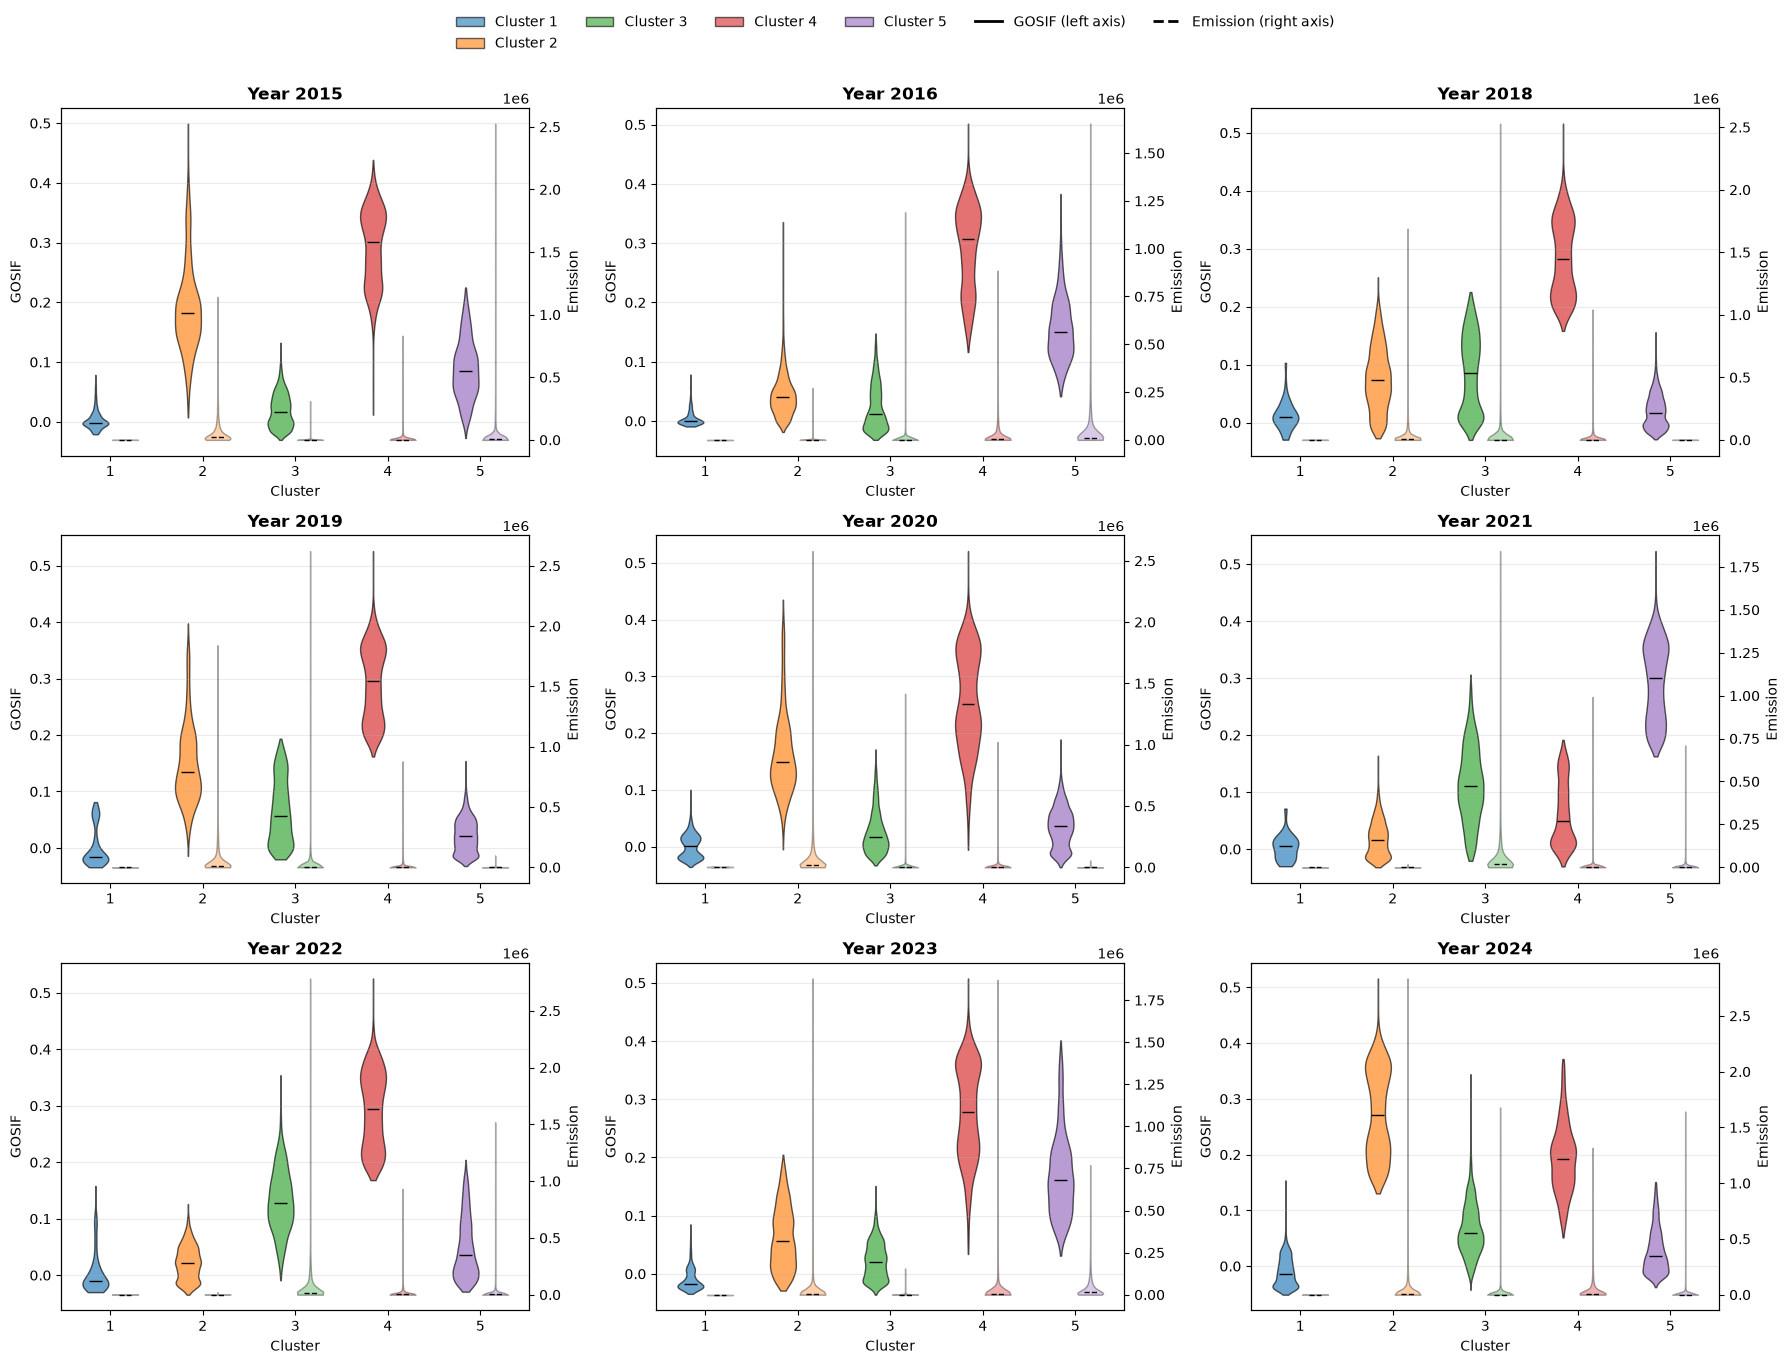

In [124]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Expect columns: year, cluster, gosif, emission in plot_df
if "plot_df" not in globals():
    raise ValueError("plot_df is not available. Run the data prep cell first.")

df = plot_df.dropna(subset=["year", "cluster", "gosif", "emission"]).copy()
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce").astype("Int64")
df = df.dropna(subset=["year", "cluster"]).copy()
df["year"] = df["year"].astype(int)
df["cluster"] = df["cluster"].astype(int)

years_to_plot = sorted(df["year"].unique())
clusters = sorted(df["cluster"].unique())
cluster_colors = dict(zip(clusters, sns.color_palette("tab10", n_colors=len(clusters))))

ncols = 3
nrows = math.ceil(len(years_to_plot) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 4.6 * nrows), sharex=False)
axs = np.array(axs).reshape(-1)

offset = 0.16
violin_width = 0.28

for i, year in enumerate(years_to_plot):
    ax_left = axs[i]
    ax_right = ax_left.twinx()
    year_data = df[df["year"] == year]
    x = np.arange(1, len(clusters) + 1)

    for j, cluster in enumerate(clusters):
        c_df = year_data[year_data["cluster"] == cluster]
        gosif_vals = c_df["gosif"].to_numpy()
        emission_vals = c_df["emission"].to_numpy()
        ccolor = cluster_colors[cluster]

        if len(gosif_vals) > 1:
            vp_g = ax_left.violinplot(
                [gosif_vals],
                positions=[x[j] - offset],
                widths=violin_width,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body in vp_g["bodies"]:
                body.set_facecolor(ccolor)
                body.set_edgecolor("black")
                body.set_alpha(0.65)
            vp_g["cmedians"].set_color("black")
            vp_g["cmedians"].set_linewidth(1.0)
            vp_g["cmedians"].set_linestyle("-")

        if len(emission_vals) > 1:
            vp_e = ax_right.violinplot(
                [emission_vals],
                positions=[x[j] + offset],
                widths=violin_width,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body in vp_e["bodies"]:
                body.set_facecolor(ccolor)
                body.set_edgecolor("black")
                body.set_alpha(0.35)
            vp_e["cmedians"].set_color("black")
            vp_e["cmedians"].set_linewidth(1.0)
            vp_e["cmedians"].set_linestyle("--")

    ax_left.set_xticks(x)
    ax_left.set_xticklabels([str(c) for c in clusters])
    ax_left.set_xlabel("Cluster")
    ax_left.set_ylabel("GOSIF")
    ax_right.set_ylabel("Emission")
    ax_left.grid(True, axis="y", alpha=0.25)
    ax_left.set_title(f"Year {year}", fontsize=12, fontweight="bold")

for j in range(len(years_to_plot), len(axs)):
    axs[j].set_visible(False)

cluster_handles = [
    Patch(facecolor=cluster_colors[c], edgecolor="black", alpha=0.6, label=f"Cluster {c}")
    for c in clusters
]
metric_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="GOSIF (left axis)"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Emission (right axis)"),
]
fig.legend(
    handles=cluster_handles + metric_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=min(6, len(cluster_handles) + len(metric_handles)),
    fontsize=10,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

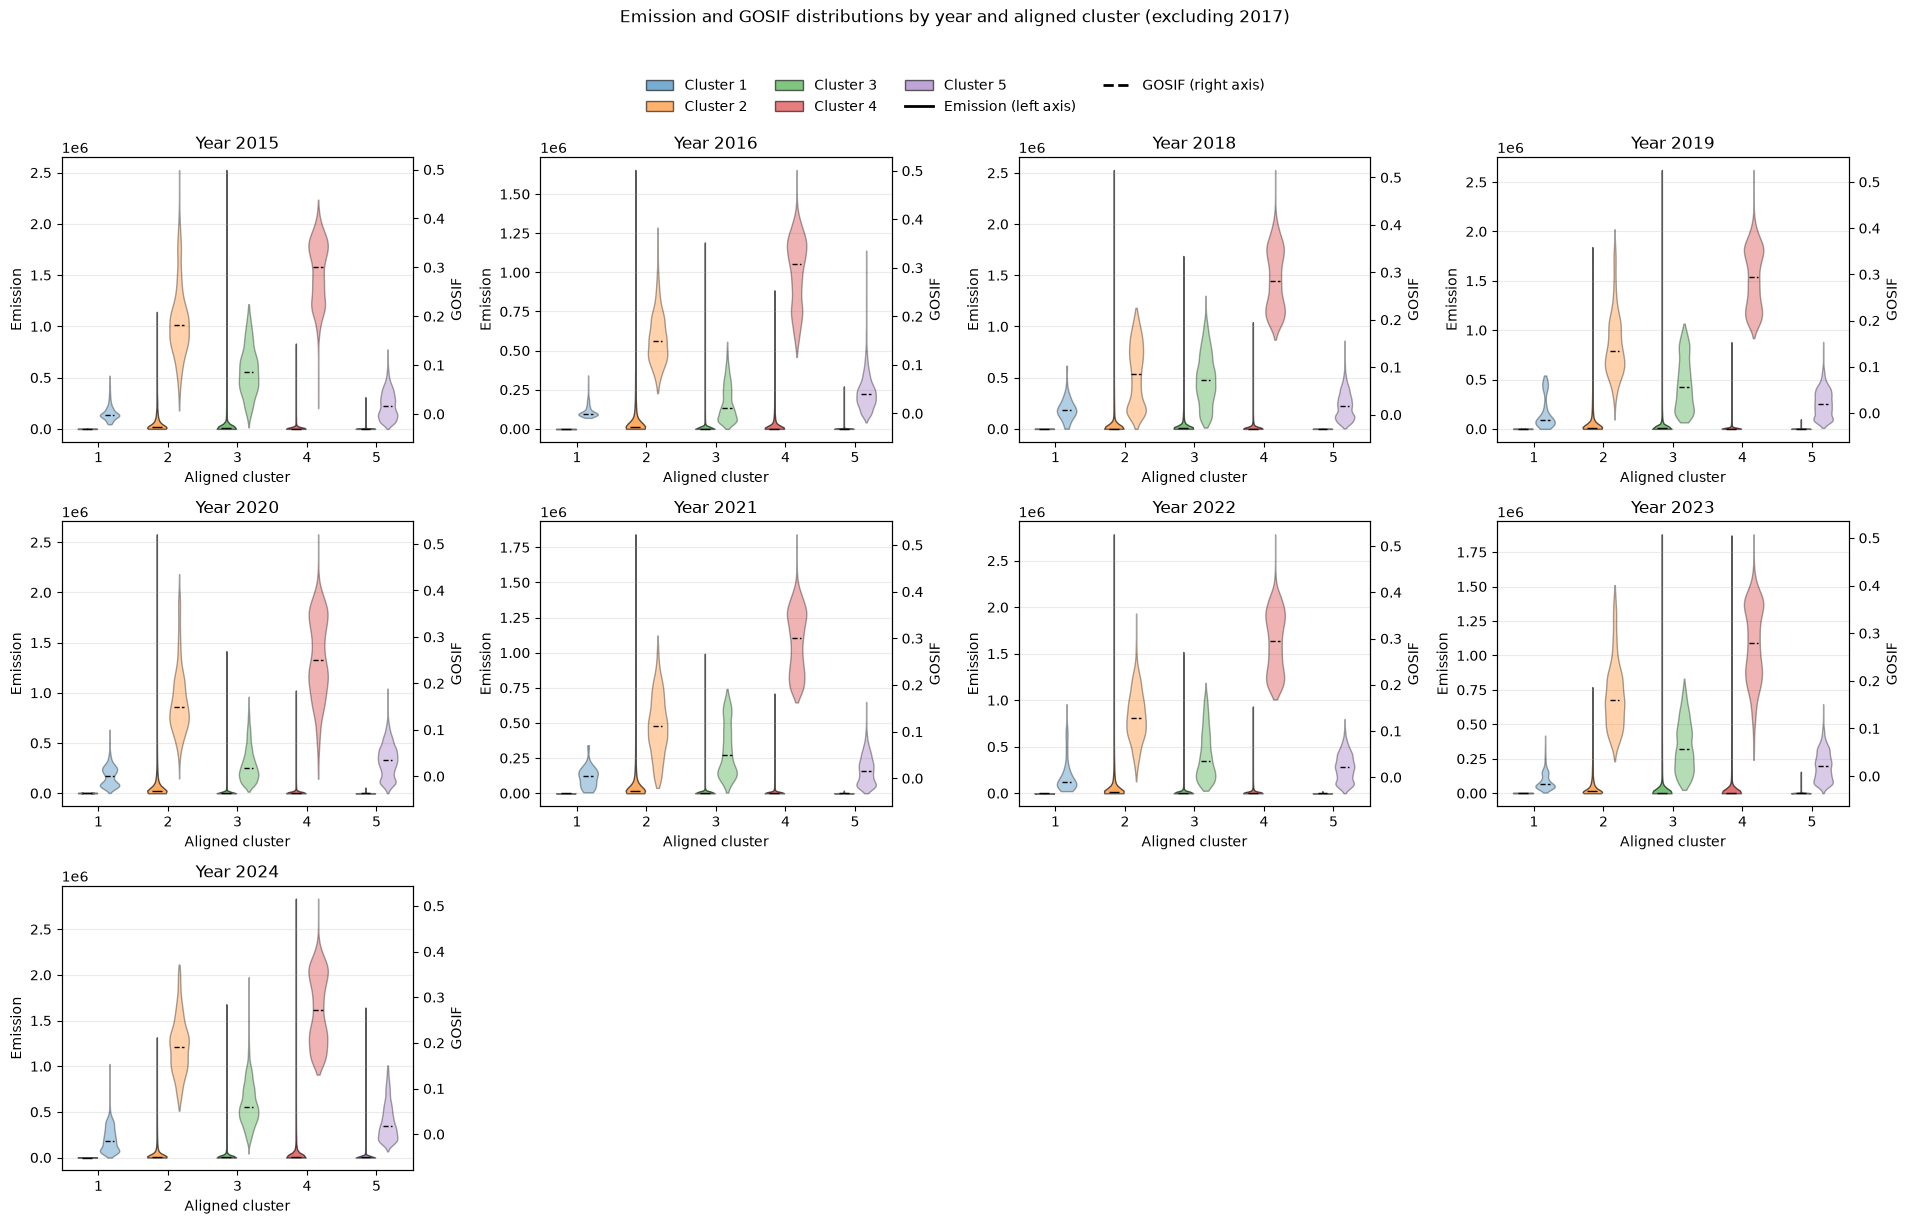

,lon,lat,aligned_cluster,cluster,year,emission,gosif,growth_rate
11522,19.5,25.5,1,1,2015,65.200455,-0.009093,1.774843
20720,-55.5,73.5,1,1,2015,0.682612,-0.006435,2.535406
19823,-88.5,68.5,1,1,2015,0.545922,-0.001724,2.374961
20495,77.5,71.5,1,1,2015,2.681393,0.027076,2.653953
20648,90.5,72.5,1,1,2015,4.207717,0.021160,2.444607


In [ ]:
import re
import math
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Load gridded data from netCDF
ds = xr.open_dataset("C:/Users/darja/Complexity72h/complexity72_2026/unified_annual_carbon_dataset_2015_2024.nc")

vars_to_plot = ["emission", "gosif", "growth_rate"]
years_to_exclude = {2017}
grid_df = ds[vars_to_plot].to_dataframe().reset_index()

# Normalize column names from possible alternatives
if "latitude" in grid_df.columns and "lat" not in grid_df.columns:
    grid_df = grid_df.rename(columns={"latitude": "lat"})
if "longitude" in grid_df.columns and "lon" not in grid_df.columns:
    grid_df = grid_df.rename(columns={"longitude": "lon"})

if "time" not in grid_df.columns:
    raise ValueError("Expected a 'time' column in the netCDF dataframe.")

# Robust year extraction: keep integer years directly when present
time_num = pd.to_numeric(grid_df["time"], errors="coerce")
if time_num.notna().any() and (time_num.dropna().between(1800, 2200).mean() > 0.8):
    grid_df["year"] = time_num.round().astype("Int64")
else:
    grid_df["year"] = pd.to_datetime(grid_df["time"], errors="coerce").dt.year.astype("Int64")

grid_df = grid_df[~grid_df["year"].isin(years_to_exclude)].copy()

# Build long point-level cluster table from all_points_aligned
cluster_cols = [
    c for c in all_points_aligned.columns
    if c.startswith("aligned_cluster_") or c.startswith("cluster_aligned_")
]
if not cluster_cols:
    raise ValueError("No aligned_cluster_<year> or cluster_aligned_<year> columns found in all_points_aligned.")

points_long_parts = []
for col in sorted(cluster_cols):
    year_match = re.search(r"(\d{4})$", col)
    if year_match is None:
        continue
    yr = int(year_match.group(1))
    if yr in years_to_exclude:
        continue

    old_col = f"kmeans_cluster_{yr}"
    use_cols = ["lon", "lat", col]
    if old_col in all_points_aligned.columns:
        use_cols.append(old_col)

    tmp = all_points_aligned[use_cols].copy()
    tmp = tmp.rename(columns={col: "aligned_cluster"})
    if old_col in tmp.columns:
        tmp = tmp.rename(columns={old_col: "cluster"})
    else:
        tmp["cluster"] = pd.NA
    tmp["year"] = yr
    points_long_parts.append(tmp)

if not points_long_parts:
    raise ValueError("No point-year data left after excluding years.")

points_long = pd.concat(points_long_parts, ignore_index=True)
points_long["year"] = pd.to_numeric(points_long["year"], errors="coerce").astype("Int64")
points_long["aligned_cluster"] = pd.to_numeric(points_long["aligned_cluster"], errors="coerce").astype("Int64")

# Make coordinate matching robust
for df_tmp in (grid_df, points_long):
    df_tmp["lon"] = pd.to_numeric(df_tmp["lon"], errors="coerce").round(5)
    df_tmp["lat"] = pd.to_numeric(df_tmp["lat"], errors="coerce").round(5)

# Ensure right side is unique per lon/lat/year
grid_unique = (
    grid_df.dropna(subset=["lon", "lat", "year"])
    .groupby(["lon", "lat", "year"], as_index=False)[vars_to_plot]
    .mean(numeric_only=True)
)

plot_df = points_long.merge(
    grid_unique,
    on=["lon", "lat", "year"],
    how="inner",
    validate="many_to_one",
)

# Keep only usable rows
plot_df = plot_df.dropna(subset=["aligned_cluster", "emission", "gosif", "growth_rate"]).copy()
plot_df["aligned_cluster"] = plot_df["aligned_cluster"].astype(int)
plot_df["year"] = plot_df["year"].astype(int)

if plot_df.empty:
    raise ValueError("Merged dataframe is empty after filtering. Check lon/lat rounding and year extraction.")

# Optional downsample per (year, aligned_cluster) for faster violin plots
MAX_PER_GROUP = 3000
rng = np.random.default_rng(42)
plot_df["_rand"] = rng.random(len(plot_df))
plot_df = (
    plot_df.sort_values(["year", "aligned_cluster", "_rand"])
    .groupby(["year", "aligned_cluster"], as_index=False, group_keys=False)
    .head(MAX_PER_GROUP)
    .drop(columns=["_rand"])
)

# Combined emission + gosif plot with dual y-axes and side-by-side violins
years_sorted = sorted(plot_df["year"].unique())
clusters_sorted = sorted(plot_df["aligned_cluster"].unique())
cluster_colors = dict(zip(clusters_sorted, sns.color_palette("tab10", n_colors=len(clusters_sorted))))

ncols = 4
nrows = math.ceil(len(years_sorted) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.8 * nrows), sharex=False)
axes = np.array(axes).reshape(-1)

offset = 0.16
violin_width = 0.28

for i, year in enumerate(years_sorted):
    ax = axes[i]
    ax2 = ax.twinx()
    df_year = plot_df[plot_df["year"] == year]
    x = np.arange(1, len(clusters_sorted) + 1)

    for j, cluster in enumerate(clusters_sorted):
        c_df = df_year[df_year["aligned_cluster"] == cluster]
        em_vals = c_df["emission"].to_numpy()
        go_vals = c_df["gosif"].to_numpy()
        color = cluster_colors[cluster]

        if len(em_vals) > 1:
            vp_em = ax.violinplot(
                dataset=[em_vals],
                positions=[x[j] - offset],
                widths=violin_width,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body in vp_em["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor("black")
                body.set_alpha(0.65)
            vp_em["cmedians"].set_color("black")
            vp_em["cmedians"].set_linewidth(1.0)

        if len(go_vals) > 1:
            vp_go = ax2.violinplot(
                dataset=[go_vals],
                positions=[x[j] + offset],
                widths=violin_width,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for body in vp_go["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor("black")
                body.set_alpha(0.35)
            vp_go["cmedians"].set_color("black")
            vp_go["cmedians"].set_linestyle("--")
            vp_go["cmedians"].set_linewidth(1.0)

    ax.set_title(f"Year {year}")
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in clusters_sorted])
    ax.set_xlabel("Aligned cluster")
    ax.set_ylabel("Emission")
    ax2.set_ylabel("GOSIF")
    ax.grid(True, axis="y", alpha=0.25)

# Hide unused subplots
for j in range(len(years_sorted), len(axes)):
    axes[j].set_visible(False)

cluster_handles = [
    Patch(facecolor=cluster_colors[c], edgecolor="black", alpha=0.6, label=f"Cluster {c}")
    for c in clusters_sorted
]
var_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Emission (left axis)"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="GOSIF (right axis)"),
]

fig.legend(
    handles=cluster_handles + var_handles,
    loc="upper center",
    ncol=min(4, len(cluster_handles) + len(var_handles)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle("Emission and GOSIF distributions by year and aligned cluster (excluding 2017)", y=1.07)
plt.tight_layout()
plt.show()

plot_df.head()

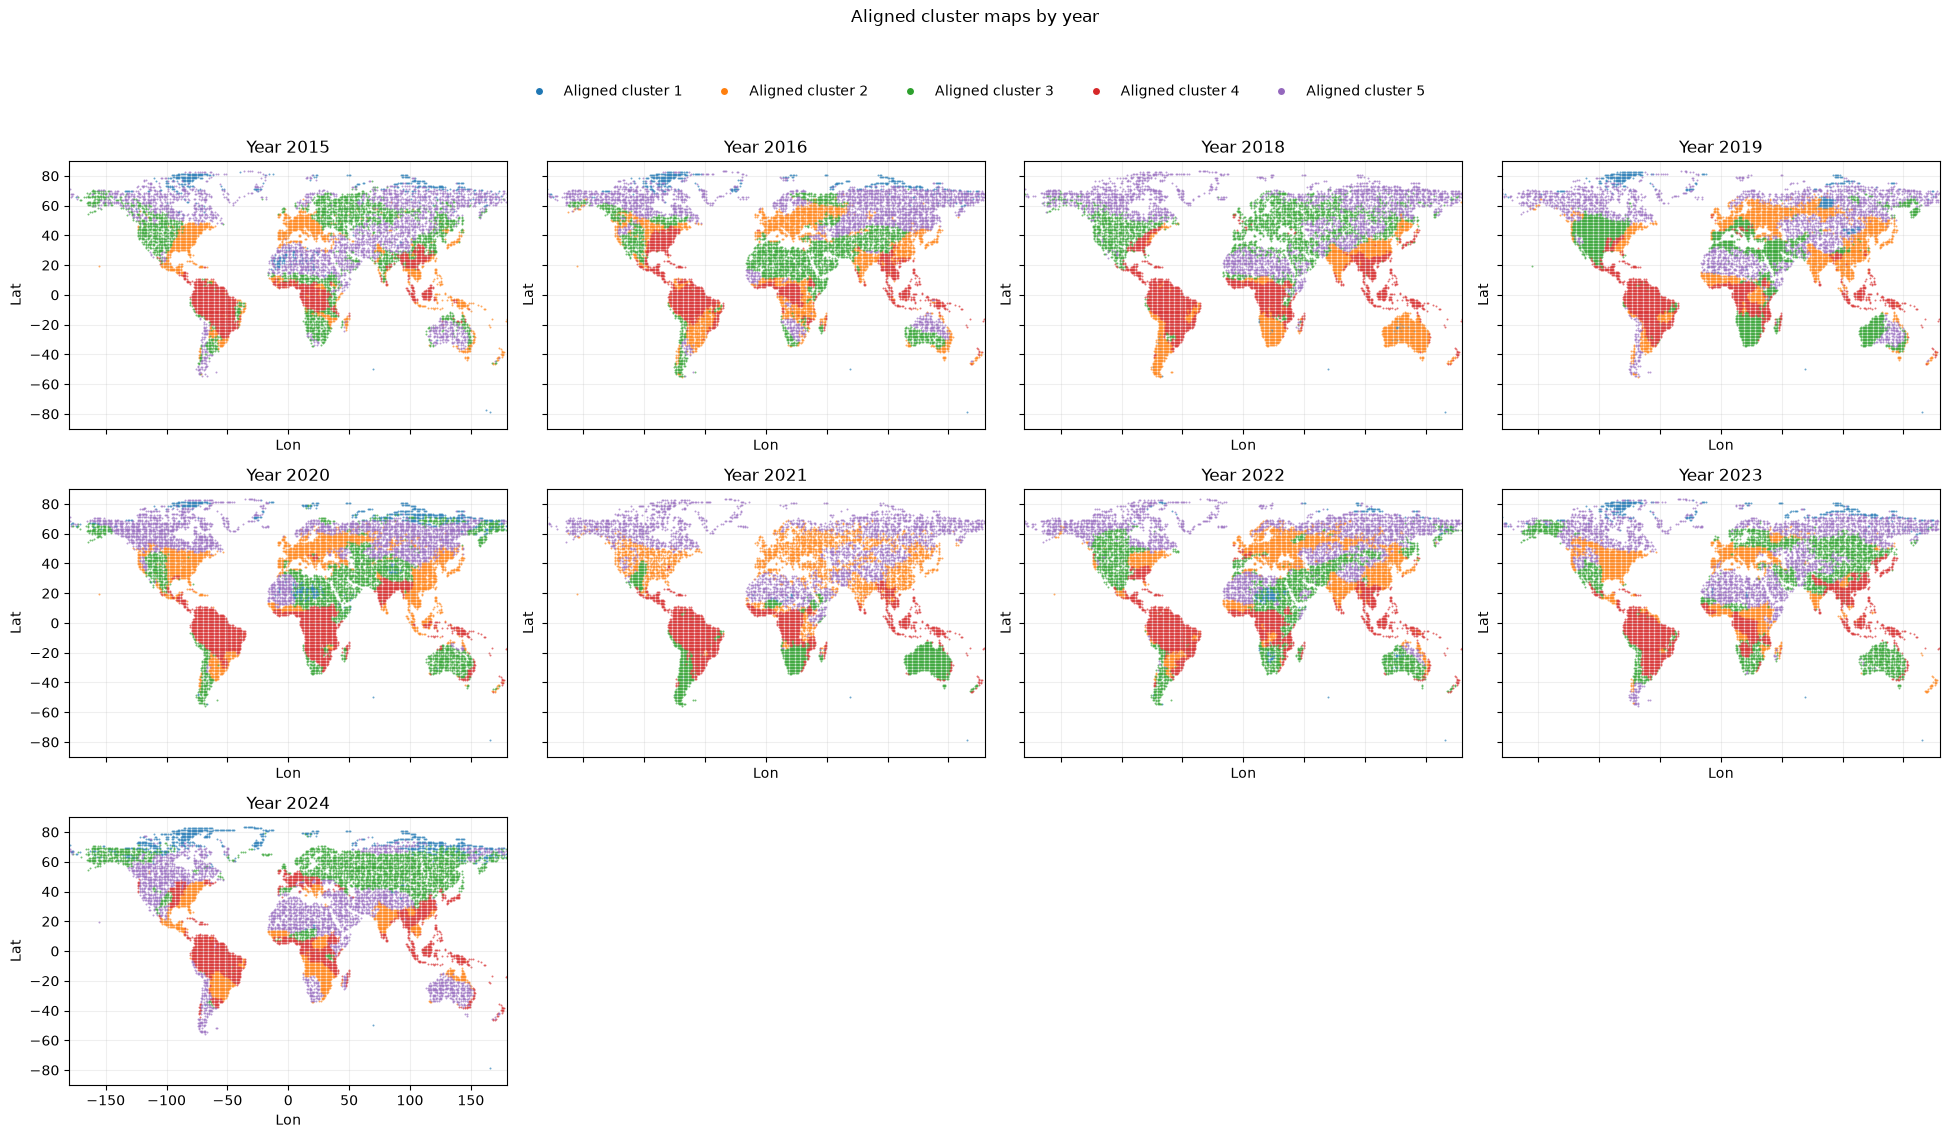

In [87]:
# Map of NEW (aligned) clusters by year
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reuse aligned-cluster table from the distribution step
if "plot_df" not in globals():
    raise ValueError("plot_df is not available. Run the distribution cell first.")
map_df_new = plot_df.dropna(subset=["aligned_cluster"]).copy()
map_df_new["aligned_cluster"] = pd.to_numeric(map_df_new["aligned_cluster"], errors="coerce")
map_df_new = map_df_new.dropna(subset=["aligned_cluster"]).copy()
map_df_new["aligned_cluster"] = map_df_new["aligned_cluster"].astype(int)

if "years_to_exclude" in globals():
    map_df_new = map_df_new[~map_df_new["year"].isin(years_to_exclude)].copy()

# Optional point downsampling per (year, aligned_cluster) to keep maps responsive
MAX_POINTS_PER_GROUP = 4000
rng = np.random.default_rng(42)
map_df_new["_rand"] = rng.random(len(map_df_new))
map_df_new = (
    map_df_new.sort_values(["year", "aligned_cluster", "_rand"])
    .groupby(["year", "aligned_cluster"], as_index=False, group_keys=False)
    .head(MAX_POINTS_PER_GROUP)
    .drop(columns=["_rand"])
)

years_map = sorted(map_df_new["year"].unique())
clusters_map = sorted(map_df_new["aligned_cluster"].unique())
cluster_colors_map = dict(zip(clusters_map, sns.color_palette("tab10", n_colors=len(clusters_map))))

ncols = 4
nrows = math.ceil(len(years_map) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.9 * ncols, 3.5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, year in enumerate(years_map):
    ax = axes[i]
    d = map_df_new[map_df_new["year"] == year]

    for c in clusters_map:
        d_c = d[d["aligned_cluster"] == c]
        if d_c.empty:
            continue
        ax.scatter(
            d_c["lon"],
            d_c["lat"],
            s=2,
            alpha=0.65,
            color=cluster_colors_map[c],
            linewidths=0,
            rasterized=True,
            label=f"C{c}",
        )

    ax.set_title(f"Year {year}")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")

for j in range(len(years_map), len(axes)):
    axes[j].set_visible(False)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cluster_colors_map[c],
               markersize=6, linestyle="", label=f"Aligned cluster {c}")
    for c in clusters_map
]
fig.legend(handles=handles, loc="upper center", ncol=min(5, len(handles)), frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Aligned cluster maps by year", y=1.08)
plt.tight_layout()
plt.show()

In [96]:
pdy=[]
for year in years:
    plot_df_year = plot_df[plot_df['year'] == year].copy()
    plot_df_year['emission_norm'] = (plot_df_year['emission'] - plot_df_year['emission'].min()) / (plot_df_year['emission'].max() - plot_df_year['emission'].min())
    plot_df_year['gosif_norm'] = (plot_df_year['gosif'] - plot_df_year['gosif'].min()) / (plot_df_year['gosif'].max() - plot_df_year['gosif'].min())

    pdy.append(plot_df_year)
plot_df_normalized = pd.concat(pdy, ignore_index=True)

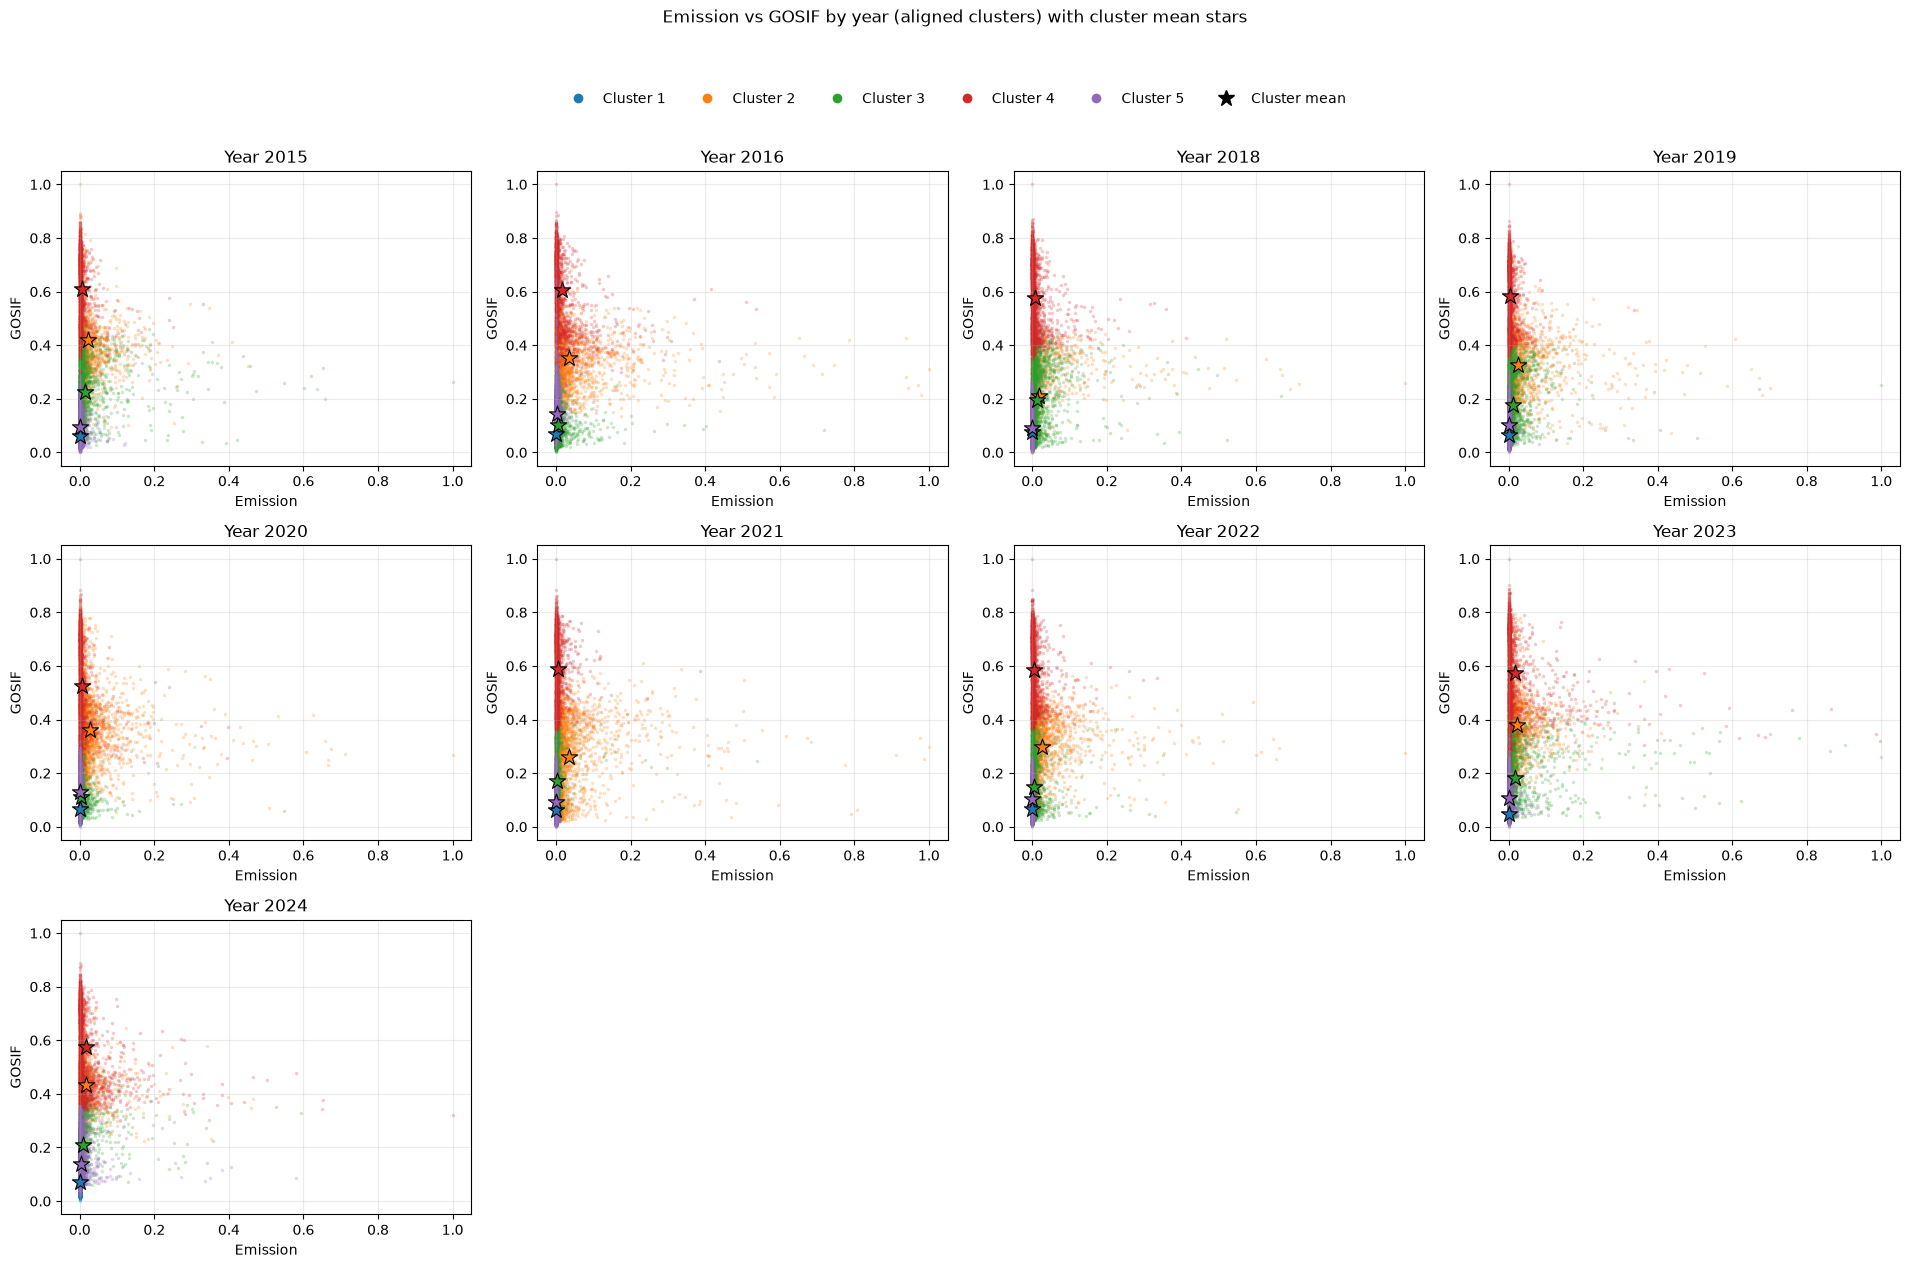

In [101]:
# Emission vs GOSIF scatter panels by year for ALIGNED clusters, with mean stars
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if "plot_df_normalized" not in globals():
    raise ValueError("plot_df_normalized is not available. Run the normalized comparison cell first.")

scatter_df = plot_df_normalized.dropna(subset=["year", "aligned_cluster", "emission_norm", "gosif_norm"]).copy()
scatter_df["year"] = pd.to_numeric(scatter_df["year"], errors="coerce").astype("Int64")
scatter_df["aligned_cluster"] = pd.to_numeric(scatter_df["aligned_cluster"], errors="coerce").astype("Int64")
scatter_df = scatter_df.dropna(subset=["year", "aligned_cluster"]).copy()
scatter_df["year"] = scatter_df["year"].astype(int)
scatter_df["aligned_cluster"] = scatter_df["aligned_cluster"].astype(int)

if "years_to_exclude" in globals():
    scatter_df = scatter_df[~scatter_df["year"].isin(years_to_exclude)].copy()

# Downsample for visual clarity/performance
MAX_POINTS_PER_GROUP = 5000
rng = np.random.default_rng(42)
scatter_df["_rand"] = rng.random(len(scatter_df))
scatter_df = (
    scatter_df.sort_values(["year", "aligned_cluster", "_rand"])
    .groupby(["year", "aligned_cluster"], as_index=False, group_keys=False)
    .head(MAX_POINTS_PER_GROUP)
    .drop(columns=["_rand"])
)

years_sorted = sorted(scatter_df["year"].unique())
clusters_sorted = sorted(scatter_df["aligned_cluster"].unique())
cluster_colors = dict(zip(clusters_sorted, sns.color_palette("tab10", n_colors=len(clusters_sorted))))

means_df = (
    scatter_df.groupby(["year", "aligned_cluster"], as_index=False)[["emission_norm", "gosif_norm"]]
    .mean()
    .rename(columns={"emission_norm": "emission_mean", "gosif_norm": "gosif_mean"})
)

ncols = 4
nrows = math.ceil(len(years_sorted) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.9 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, year in enumerate(years_sorted):
    ax = axes[i]
    d = scatter_df[scatter_df["year"] == year]
    d_mean = means_df[means_df["year"] == year]

    for c in clusters_sorted:
        d_c = d[d["aligned_cluster"] == c]
        if d_c.empty:
            continue
        color = cluster_colors[c]

        ax.scatter(
            d_c["emission_norm"],
            d_c["gosif_norm"],
            s=6,
            alpha=0.25,
            color=color,
            linewidths=0,
            rasterized=True,
        )

        m_c = d_mean[d_mean["aligned_cluster"] == c]
        if not m_c.empty:
            ax.scatter(
                m_c["emission_mean"],
                m_c["gosif_mean"],
                s=150,
                marker="*",
                color=color,
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )

    ax.set_title(f"Year {year}")
    ax.set_xlabel("Emission")
    ax.set_ylabel("GOSIF")
    ax.grid(True, alpha=0.25)

for j in range(len(years_sorted), len(axes)):
    axes[j].set_visible(False)

cluster_handles = [
    Line2D([0], [0], marker="o", color="w", label=f"Cluster {c}",
           markerfacecolor=cluster_colors[c], markeredgecolor="none", markersize=7)
    for c in clusters_sorted
]
mean_handle = Line2D([0], [0], marker="*", color="black", label="Cluster mean", linestyle="", markersize=12)

fig.legend(
    handles=cluster_handles + [mean_handle],
    loc="upper center",
    ncol=min(6, len(cluster_handles) + 1),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle("Emission vs GOSIF by year (aligned clusters) with cluster mean stars", y=1.08)
plt.tight_layout()
plt.show()

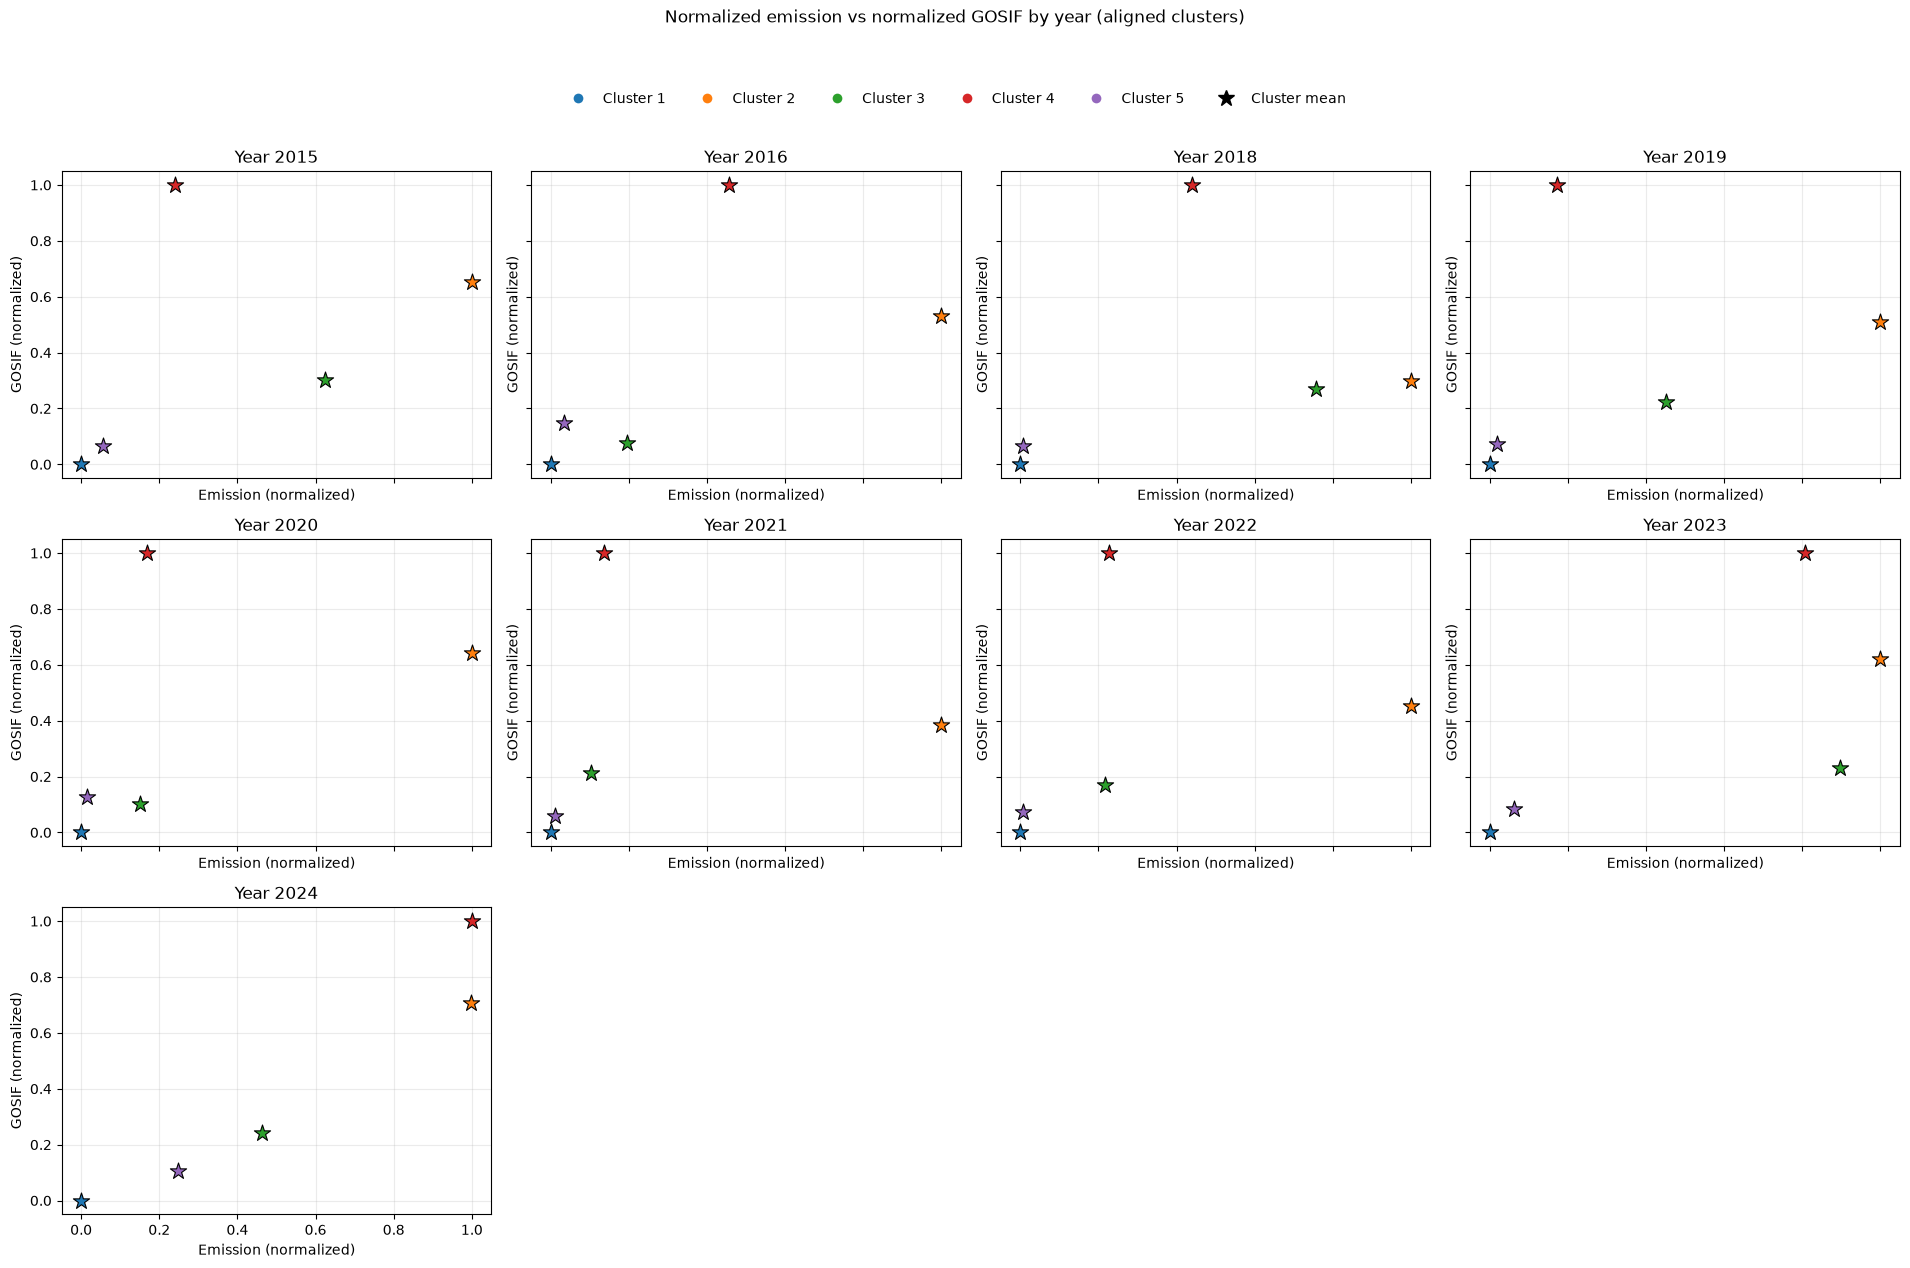

,lon,lat,aligned_cluster,emission_norm,gosif_norm,year
18983,-116.5,65.5,1,0.0,0.0,2015
5481,96.5,-71.5,1,0.0,0.0,2015
1157,-102.5,-86.5,1,0.0,0.0,2015
1836,-121.5,-84.5,1,0.0,0.0,2015
3502,47.5,-79.5,1,0.0,0.0,2015


In [91]:
# Emission_norm vs GOSIF_norm scatter panels by year for ALIGNED clusters, from table columns
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if "all_points_aligned" not in globals():
    raise ValueError("all_points_aligned is not available. Run the mapping cell first.")

years_to_exclude_local = years_to_exclude if "years_to_exclude" in globals() else {2017}

aligned_cols = [
    c for c in all_points_aligned.columns
    if c.startswith("aligned_cluster_")
 ]
if not aligned_cols:
    raise ValueError("No aligned_cluster_<year> columns found in all_points_aligned.")

parts = []
for c_aligned in sorted(aligned_cols):
    m = re.search(r"(\d{4})$", c_aligned)
    if m is None:
        continue
    yr = int(m.group(1))
    if yr in years_to_exclude_local:
        continue

    c_em = f"emission_norm_{yr}"
    c_go = f"gosif_norm_{yr}"
    if c_em not in all_points_aligned.columns or c_go not in all_points_aligned.columns:
        continue

    tmp = all_points_aligned[["lon", "lat", c_aligned, c_em, c_go]].copy()
    tmp = tmp.rename(columns={
        c_aligned: "aligned_cluster",
        c_em: "emission_norm",
        c_go: "gosif_norm",
    })
    tmp["year"] = yr
    parts.append(tmp)

if not parts:
    raise ValueError("No normalized per-year columns found to build scatter panels.")

norm_df = pd.concat(parts, ignore_index=True)
norm_df["aligned_cluster"] = pd.to_numeric(norm_df["aligned_cluster"], errors="coerce").astype("Int64")
norm_df["emission_norm"] = pd.to_numeric(norm_df["emission_norm"], errors="coerce")
norm_df["gosif_norm"] = pd.to_numeric(norm_df["gosif_norm"], errors="coerce")
norm_df = norm_df.dropna(subset=["year", "aligned_cluster", "emission_norm", "gosif_norm"]).copy()
norm_df["year"] = norm_df["year"].astype(int)
norm_df["aligned_cluster"] = norm_df["aligned_cluster"].astype(int)

# Downsample for plotting speed/clarity
MAX_POINTS_PER_GROUP = 5000
rng = np.random.default_rng(42)
norm_df["_rand"] = rng.random(len(norm_df))
norm_df = (
    norm_df.sort_values(["year", "aligned_cluster", "_rand"])
    .groupby(["year", "aligned_cluster"], as_index=False, group_keys=False)
    .head(MAX_POINTS_PER_GROUP)
    .drop(columns=["_rand"])
)

means_df = (
    norm_df.groupby(["year", "aligned_cluster"], as_index=False)[["emission_norm", "gosif_norm"]]
    .mean()
    .rename(columns={"emission_norm": "emission_norm_mean", "gosif_norm": "gosif_norm_mean"})
)

years_sorted = sorted(norm_df["year"].unique())
clusters_sorted = sorted(norm_df["aligned_cluster"].unique())
cluster_colors = dict(zip(clusters_sorted, sns.color_palette("tab10", n_colors=len(clusters_sorted))))

ncols = 4
nrows = math.ceil(len(years_sorted) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.9 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, year in enumerate(years_sorted):
    ax = axes[i]
    d = norm_df[norm_df["year"] == year]
    d_mean = means_df[means_df["year"] == year]

    for c in clusters_sorted:
        d_c = d[d["aligned_cluster"] == c]
        if d_c.empty:
            continue
        color = cluster_colors[c]

        ax.scatter(
            d_c["emission_norm"],
            d_c["gosif_norm"],
            s=6,
            alpha=0.25,
            color=color,
            linewidths=0,
            rasterized=True,
        )

        m_c = d_mean[d_mean["aligned_cluster"] == c]
        if not m_c.empty:
            ax.scatter(
                m_c["emission_norm_mean"],
                m_c["gosif_norm_mean"],
                s=150,
                marker="*",
                color=color,
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )

    ax.set_title(f"Year {year}")
    ax.set_xlabel("Emission (normalized)")
    ax.set_ylabel("GOSIF (normalized)")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.25)

for j in range(len(years_sorted), len(axes)):
    axes[j].set_visible(False)

cluster_handles = [
    Line2D([0], [0], marker="o", color="w", label=f"Cluster {c}",
           markerfacecolor=cluster_colors[c], markeredgecolor="none", markersize=7)
    for c in clusters_sorted
]
mean_handle = Line2D([0], [0], marker="*", color="black", label="Cluster mean", linestyle="", markersize=12)

fig.legend(
    handles=cluster_handles + [mean_handle],
    loc="upper center",
    ncol=min(6, len(cluster_handles) + 1),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
fig.suptitle("Normalized emission vs normalized GOSIF by year (aligned clusters)", y=1.08)
plt.tight_layout()
plt.show()

norm_df.head()